In [1]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root ="./data",
    train=True,
    download=True,
    transform=transform
)

print(len(train_dataset))

100.0%
100.0%
100.0%
100.0%

60000


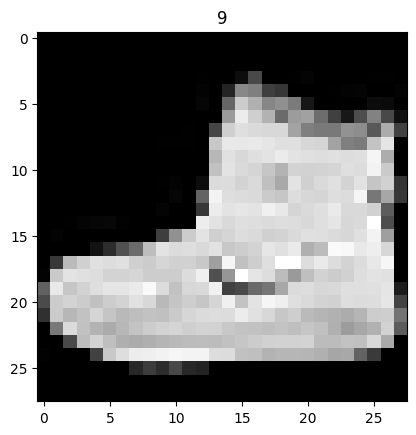

In [2]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.imshow(image.squeeze(), cmap='gray')
plt.title(label)
plt.show()

In [3]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([1, 28, 28])
9


In [4]:
labels_map = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

print(labels_map[label])

Ankle boot


In [ ]:
# 데이터 로드
from torchvision import datasets, transforms
import torch

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root= "./data",
    train = True,
    download= True,
    transform=transform
)

# train/valid 분리
from torch.utils.data import random_split

train_dataset, valid_dataset = random_split(
    train_dataset, [48000, 12000]
)

# 데이터 셋/데이터 로더 만들기
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size= 64, shuffle=True) # 데이터를 한번에 64개씩 잘라서 모델에 넣어주는 역할 / 전체데이터를 한번에 넣으면 너무 느리고 메모리가 터지기 때문
valid_loader = DataLoader(valid_dataset, batch_size= 64, shuffle=False) # 배치사이즈 = 데이터를 몇개씩 묶어서 넣을건지 / 셔플은 데이터를 섞어 넣을건지 유무

# CNN모델 만들기
import torch.nn as nn

class DeepCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,32, kernel_size=3, padding=1) # Conv = Convolution / 2d = 2차원 이미지를 다룸 2차원 이미지에서 특징을 뽑는 층 / (입력 채널 / 출력 채널 / 커널사이즈 / 패딩사이즈) 입력채널 1은 흑백 conv를 거치면 출력채널만큼 늘어남 특징사진 32개 만들기때문
        self.bn = nn.BatchNorm2d(32) # 32채널 정규화 / 데이터 안정화

        self.conv2 = nn.Conv2d(32,64,kernel_size=3,padding=1) # kernel_size = ?x?크기의 작은 창으로 이미지를 분석 조금씩 보며 선,점,모서리 같은 패턴을 찾음
                                                              # padding =  이미지 가장자리에 0을 덧붙여 Convolution 할 때 이미지 가장자리 손실을 없애기 위해 사용
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64,128, kernel_size = 3, padding = 1)
        self.bn3 = nn.BatchNorm2d(128)

        self.relu = nn.ReLU() # ReLU =  Rectified Linear Unit의 줄임말 음수는 0 양수는 그대로 변형시키는 언어 / 불필요한 음수 신호를 제거하고 비선형성을 주기 위해 사용
                              # 복잡한 곡선, 복잡한 패턴, 비선형 관계를 학습하고 여러층을 쌓는 딥러닝 과정에서 선형계산만 하면 하나의 단순한 선형모델이 될 수 있으니 사용함

        self.pool = nn.MaxPool2d(2,2) # Maximum pooling의 줄임말 / 이미지 크기를 줄이는 층 >> 예를 들어 2x2 구역을 보고 그안에서 가장 큰 값 하나만 남기는 것.
                                      # (2,2)는 커널사이즈2,스트라이드2를 뜻함 2x2칸씩 보고 2칸씩 이동하는것 / 중요한 특징, 계산량 감소, 위치변화에 덜 예민한 모델을 만들기위함

        self.dropout = nn.Dropout(0.3) # 뉴런 랜덤 제거 30% / 모델 성능 향상 도움

        

        self.fc1 = nn.Linear(128 * 3 * 3, 128) # Linear는 완전연결층(Fully Connected Layer) 앞에서 뽑아낸 특징들을 종합해 판단하는 단계
        self.fc2 = nn.Linear(128,10)          # 즉 Conv는 특징찾기, Linear는 최종 분류하기
                                              # (64*7*7은) conv와 pooling을 거친 데이터 모양이 (배치크기,64,7,7)이렇게 나오기 때문에 Linear에 넣기위해 한줄로 펴려면
                                              # 64 * 7 * 7 = 3136 즉 입력 노드 수는 3136개 / 뒷숫자인 128은 출력할 노드 개수 / 3136개의 특징을 128개로 압축시키는 작업 
                                              # 마지막 128,10은 숫자가 0,1,2,3,4,5,6,7,8,9 총 10개의 클래스니 마지막 10개의 점수를 내고 가장 큰점수를 가진 번호를 예측해 고름
                                              # (128*3*3)에서 3을 곱하는 이유는 14 -> 7 -> 3 // 7/2 = 3.5 근데 float을 해서 소수점을 버리기 때문에 3이됨

    def forward(self,x): # forward == 모델의 설계도
        x = self.pool(self.relu(self.conv1(x))) # (1,28,28) => (32,14,14)로 변경
        x = self.pool(self.relu(self.conv2(x))) # (32,14,14) => (64,7,7)로 변경
        x = self.pool(self.relu(self.conv3(x))) # (64,7,7) => (128,3,3)로 변경

        x = x.view(x.size(0), -1) # 펼치기 x.size(0)은 배치 크기64, -1은 나머지는 자동계산으로 설정 / 결과ex) (64,3136)
        x = self.relu(self.fc1(x)) # 특징 압축
        x = self.fc2(x) # 최종 출력
        return x

# 모델/손실함수/옵티마이저 준비
model = DeepCNN() # 모델 생성

criterion = nn.CrossEntropyLoss() # Cross = 교차 / Entropy = 정보량(불확실성) / Loss = 손실(틀린 정도) / 예측과 정답이 얼마나 다른지 계산하는 함수
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001) # optimizer = 최적화 도구 / 틀린만큼 모델을 어떻게 고칠지 결정
                                                            # Adam = Adaptive Moment Estimation 똑똑하게 가중치를 수정해주는 알고리즘
                                                            # model.parameters() = 모델 안의 모든 가중치(weight) Ex) Conv, Linear
                                                            # lr = Learning rate / 얼마나 크게 수정시킬지 / 너무 크면 왔다갔다 폭발, 너무작으면 너무느려서 거의안배움

# 학습 코드
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # GPU or CPU Mac은 NVIDIA CUDA를 지원안해서 CPU
model = model.to(device) # 모델을 CPU에 적용시키는 작업 / 데이터와 모델은 같은 장치에 있어야함

epochs = 7 # 반복 횟수 / 훈련 데이터 전체를 한바퀴 다보는게 1 epoch
best_acc = 0 # 최고 좋은 epoch를 찾는 변수
patience = 2
counter = 0

for epoch in range(epochs): # epoch 횟수만큼 학습 반복
    model.train() # 모델을 학습모드로 전환 training
    train_loss = 0 # epoch동안 손실을 누적해서 기록하기 위한 변수

    for images, labels in train_loader: # train 데이터를 batch단위로 하나씩 꺼내오기
        images, labels = images.to(device), labels.to(device) # 데이터들도 model과 같은 디바이스로 옮겨주기

        optimizer.zero_grad() # 이전 batch에서 계산된 기울기를 초기화 / Pytorch는 기울기를 계속 누적하는데 초기화를 안하면 이전것과 이번것이 섞여버림 / 이번 batch 기준으로 업데이트
        outputs = model(images) # 모델이 이미지를 보고 예측값 생성 / ex) (64,10).. 64장의 이미지 각 이미지마다 10개의 숫자에 대한 점수가 10개
        loss = criterion(outputs, labels) # 모델 예측이 정답과 얼마나 다른지 계산 / 예를들어 정답이 2인데 모델이 2에 높은점수를 주면 loss가 낮고, 다른수에 높은점수를 주면 loss가 높다.
        loss.backward() # 위에서 계산한 오차를 바탕으로 어떤 가중치를 얼마나 고쳐야 하는지 계산하는 작업 / 틀린 원인을 뒤로 거슬러 올라가며 각 가중치의 책임을 계산 (정답 비교-> 오차 계산-> 뒤로 전달)
        optimizer.step() # 방금 계산한 기울기(gradient)를 이용해 실제로 가중치를 수정 / loss.backward() = 오답 분석, optimizer.step() = 실제 수정

        train_loss += loss.item() # 현재 batch의 loss를 숫자로 꺼내서 변수에 누적 / loss.item()은 tensor형태(파이썬숫자)라서 출력용 숫자로 변형하기위해 .item()을 사용
        avg_train_loss = train_loss / len(train_loader)

    model.eval() # 모델을 평가모드로 전환
    correct = 0 # 검증 데이터에서 맞춘 개수 카운트하려는 변수
    total = 0 # 검증 데이터의 전체 개수 카운트하는 변수

    with torch.no_grad(): # 검증할 때에는 gradient 계산하지 말라는 명령어 / 검증할때에는 학습 안하고 평가만 하니 역전파용 계산이 무쓸모.
        for images, labels in valid_loader: # 검증 데이터도 batch 단위로 꺼내오기 단, 이곳에선 train처럼 학습하지 않고 평가만 함.
            images, labels = images.to(device), labels.to(device)
            outputs = model(images) # 검증 데이터에 대해 모델의 예측
            _, predicted = torch.max(outputs, 1) # torch.max(outputs, 1)은 가장 큰값, 그 위치(index)를 반환하는데 우리는 index만 필요하니 앞의 값은 버려줌.
                                                 # 1의 의미는 Pytorch에서 0은 세로방향(행) 1이 가로방향(열)을 의미
                                                 # 코드 의미: 각 행(= 각 이미지)에 대해 가장 큰 값과 그 위치를 찾아라 / 각 행에서 가로방향으로 최대값 찾기 > 열방향으로 움직이며 계산
                                                 # dim = 그 축을 없애면서 연산, dim=1 > 열 방향으로 계산 > 행마다 결과
                                                 # dim=0 > 행 방향으로 계산 > 열마다 결과 / dim은 어느방향으로 훑을지!

            total += labels.size(0) # 이번 batch의 데이터 개수를 total에 더해주기. batch size가 64면 한번에 64추가
            correct += (predicted == labels).sum().item() # 이번 batch에서 맞춘 개수 세기 >> 예측과 정답을 비교해서 .sum()으로 True를 1처럼 세서 계산 후 .item()으로 숫자로 바꿔줌

        accuracy = correct / total # 전체 중에서 맞춘 비율

        if accuracy > best_acc: # best_acc변수에 계속 최고 accuracy를 넣어줌
            best_acc = accuracy 
            torch.save(model.state_dict(), "best_model.pth") # 현재 모델의 학습된 가중치를 파일로 저장, 모델에 학습된 모든 값을 파이썬 객체 파일로 저장하는 함수, .pth는 파일 확장자+저장할 파일이름
                                                             # state_dict는 모델이 학습한 모든 지식(뇌)라고 생각하면 됨. 
            counter = 0 # 카운터 초기화
        else:
            counter += 1 # 최고 accuracy보다 안좋은 accuracy가 나온 횟수를 카운트
        
        if counter >= patience:
            print("Early Stopping!")
            break
        
        # 추후에 파일 불러와서 사용할 때
        # model = DeepCNN()  구조 먼저 만들고
        # model.load_state_dict(torch.load("best_model.pth")) 파일 불러오기
        # model.eval() 시험 모드 시작
        
        print(f"Epoch {epoch+1}/{epochs}, Train loss: {avg_train_loss:.4f}, Valid Accuracy: {accuracy:.4f}") # 현재 epoch의 학습상태 출력

# # test 데이터용 DataLoader 만들기
# test_dataset = TensorDataset(test_X)
# test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# # 예측
# model.eval()
# predictions = []

# with torch.no_grad():
#     for images in test_loader:
#         images = images[0].to(device)
#         outputs = model(images)
#         _, predicted = torch.max(outputs, 1)
#         predictions.extend(predicted.cpu().numpy())

# # 제출 파일 생성
# submission = pd.DataFrame({
#     "ImageId": range(1, len(predictions) + 1),
#     "Label": predictions
# })

# submission.to_csv("submission_digit.csv", index=False)
# submission.head()

# # 결과 정리
# # Best Valid Accuracy: 0.9851
# # Kaggle Score: 0.98425
# # Kaggle Rank: 616


Epoch 1/7, Train loss: 0.5771, Valid Accuracy: 0.8760
Epoch 2/7, Train loss: 0.3400, Valid Accuracy: 0.8866
Epoch 3/7, Train loss: 0.2842, Valid Accuracy: 0.9022
Epoch 4/7, Train loss: 0.2516, Valid Accuracy: 0.9049
Epoch 5/7, Train loss: 0.2272, Valid Accuracy: 0.9152
Epoch 6/7, Train loss: 0.2038, Valid Accuracy: 0.9187
Epoch 7/7, Train loss: 0.1845, Valid Accuracy: 0.9164


<Figure size 1000x1000 with 0 Axes>

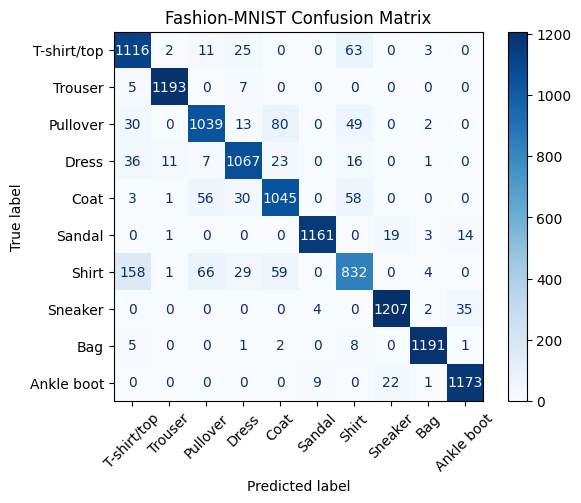

In [4]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 클래스 이름
labels_map = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

class_names = [labels_map[i] for i in range(10)]

# 저장한 최고 모델 불러오기
model = DeepCNN() # DeepCNN 구조의 빈모델 하나 만들기
model.load_state_dict(torch.load("best_model.pth")) # 베스트모델 파일안에 저장된 최고성능일때의 가중치를 현재 모델에 적용 / load_state_dict = 읽어온 가중치 모델안에 적용하기
                                                    # torch.load 파일안에 저장된 가중치 정보를 읽어오기
model = model.to(device)
model.eval()

all_preds = [] # 모든 예측값을 모아둘 리스트
all_labels = [] # 모든 정답값을 모아둘 리스트 / confusion matrix는 데이터 전체기준으로 만들어야해서 한 batch씩 예측한걸 전부 모아야함

with torch.no_grad(): # 평가할 때 gradient 계산 X
    for images, labels in valid_loader: # valid 데이터를 설정한 batch 크기 값씩 꺼내오기
        images, labels = images.to(device), labels.to(device)

        outputs = model(images) # 현재 batch 이미지들에 대해 모델이 예측점수를 계산 / shape => (64, 10) 10개의 클래스 각각 점수 부여
        _,predicted = torch.max(outputs, 1) # 가장 큰 점수의 클래스 고르기

        all_preds.extend(predicted.cpu().numpy()) # 이번 batch의 예측 결과를 전체 예측 리스트에 추가 numpy 배열로 바꿔주기 extend 리스트 뒤에 값들 하나씩 이어붙이기
        all_labels.extend(labels.cpu().numpy()) # append는 리스트안에 배열하나가 통째로 들어가서 extend로 배열 안의 값들을 하나씩 추가해줘야함 / 이번 batch의 정답도 전체 정답리스트에 추가
                                                # confusion matrix에는 예측값 vs 실제값이라 둘다 있어야 계산이 가능하다.

# confusion matrix 계산
cm = confusion_matrix(all_labels, all_preds) # 전체 정답과 전체 예측을 비교해서 10x10 표를 만듬 / 행(row) = 실제 정답, 열(column) = 모델 예측 즉, cm[실제][예측] 
                                             # 만약 cm[9][9]가 크면 정답인 ankle boot인 이미지를 잘 맞췄다 라는 뜻 cm[6][0]이 크면 정답은 shirt인데 모델이 T-shirt/top으로 자주 틀렸다는것.

# 시각화
plt.figure(figsize=(10,10)) # 출력할 그림 크기 10x10 설정
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= class_names) # 계산한 confusion matrix를 클래스이름과 함께 보기 좋게 그릴 준비 / confusion_matrix = 우리가 만든 표, display_labels = 숫자 대신 클래스 이름붙이기
disp.plot(cmap="Blues", xticks_rotation=45) # cmap = Blues: 파란색 계열로 시각화, xticks_rotation = 45: x축의 글자를 45도 기울여서 보기좋게 출력하라
plt.title("Fashion-MNIST Confusion Matrix") # 그래프 제목 달기
plt.show()

In [ ]:
# 데이터 로드
from torchvision import datasets, transforms
import torch

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root= "./data",
    train = True,
    download= True,
    transform=transform
)

# train/valid 분리
from torch.utils.data import random_split

train_dataset, valid_dataset = random_split(
    train_dataset, [48000, 12000]
)

# 데이터 셋/데이터 로더 만들기
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size= 64, shuffle=True) # 데이터를 한번에 64개씩 잘라서 모델에 넣어주는 역할 / 전체데이터를 한번에 넣으면 너무 느리고 메모리가 터지기 때문
valid_loader = DataLoader(valid_dataset, batch_size= 64, shuffle=False) # 배치사이즈 = 데이터를 몇개씩 묶어서 넣을건지 / 셔플은 데이터를 섞어 넣을건지 유무

import torch.nn as nn

class BetterCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential( # 특징 추출 (Conv 영역)
            nn.Conv2d(1, 32, kernel_size=3, padding= 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32,32, kernel_size=3, padding= 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), #28 -> 14

            nn.Conv2d(32,64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64,64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), #14 -> 7

            nn.Conv2d(64,128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 7 -> 3

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.classifier = nn.Sequential( # 분류 (Linear 영역)
            nn.Flatten(), # Linear가 원하는 입력 형태는 2차원 입력(batch_size, feature 수) 예 (64개의 데이터, 1152개의 특징) 인데 flatten(=x.view(x.size(0),-1))같은 평면화 하지않으면 (64, 128, 3, 3) 이렇게 생김
                          # flatten은 모양을 바꾸는 작업 이 밑의 Linear는 데이터를 학습하는 작업
            nn.Linear(128 * 3 * 3, 256), # 1152개의 특징 -> 256개의 중요한 특징으로 압축
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
        
# 모델/손실함수/옵티마이저 준비
model = BetterCNN() # 모델 생성

criterion = nn.CrossEntropyLoss() # Cross = 교차 / Entropy = 정보량(불확실성) / Loss = 손실(틀린 정도) / 예측과 정답이 얼마나 다른지 계산하는 함수
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001) # optimizer = 최적화 도구 / 틀린만큼 모델을 어떻게 고칠지 결정
                                                            # Adam = Adaptive Moment Estimation 똑똑하게 가중치를 수정해주는 알고리즘
                                                            # model.parameters() = 모델 안의 모든 가중치(weight) Ex) Conv, Linear
                                                            # lr = Learning rate / 얼마나 크게 수정시킬지 / 너무 크면 왔다갔다 폭발, 너무작으면 너무느려서 거의안배움

# 학습 코드
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # GPU or CPU Mac은 NVIDIA CUDA를 지원안해서 CPU
model = model.to(device) # 모델을 CPU에 적용시키는 작업 / 데이터와 모델은 같은 장치에 있어야함

epochs = 10 # 반복 횟수 / 훈련 데이터 전체를 한바퀴 다보는게 1 epoch
best_acc = 0 # 최고 좋은 epoch를 찾는 변수
patience = 2
counter = 0

for epoch in range(epochs): # epoch 횟수만큼 학습 반복
    model.train() # 모델을 학습모드로 전환 training
    train_loss = 0 # epoch동안 손실을 누적해서 기록하기 위한 변수

    for images, labels in train_loader: # train 데이터를 batch단위로 하나씩 꺼내오기
        images, labels = images.to(device), labels.to(device) # 데이터들도 model과 같은 디바이스로 옮겨주기

        optimizer.zero_grad() # 이전 batch에서 계산된 기울기를 초기화 / Pytorch는 기울기를 계속 누적하는데 초기화를 안하면 이전것과 이번것이 섞여버림 / 이번 batch 기준으로 업데이트
        outputs = model(images) # 모델이 이미지를 보고 예측값 생성 / ex) (64,10).. 64장의 이미지 각 이미지마다 10개의 숫자에 대한 점수가 10개
        loss = criterion(outputs, labels) # 모델 예측이 정답과 얼마나 다른지 계산 / 예를들어 정답이 2인데 모델이 2에 높은점수를 주면 loss가 낮고, 다른수에 높은점수를 주면 loss가 높다.
        loss.backward() # 위에서 계산한 오차를 바탕으로 어떤 가중치를 얼마나 고쳐야 하는지 계산하는 작업 / 틀린 원인을 뒤로 거슬러 올라가며 각 가중치의 책임을 계산 (정답 비교-> 오차 계산-> 뒤로 전달)
        optimizer.step() # 방금 계산한 기울기(gradient)를 이용해 실제로 가중치를 수정 / loss.backward() = 오답 분석, optimizer.step() = 실제 수정

        train_loss += loss.item() # 현재 batch의 loss를 숫자로 꺼내서 변수에 누적 / loss.item()은 tensor형태(파이썬숫자)라서 출력용 숫자로 변형하기위해 .item()을 사용
    avg_train_loss = train_loss / len(train_loader)

    model.eval() # 모델을 평가모드로 전환
    correct = 0 # 검증 데이터에서 맞춘 개수 카운트하려는 변수
    total = 0 # 검증 데이터의 전체 개수 카운트하는 변수

    with torch.no_grad(): # 검증할 때에는 gradient 계산하지 말라는 명령어 / 검증할때에는 학습 안하고 평가만 하니 역전파용 계산이 무쓸모.
        for images, labels in valid_loader: # 검증 데이터도 batch 단위로 꺼내오기 단, 이곳에선 train처럼 학습하지 않고 평가만 함.
            images, labels = images.to(device), labels.to(device)
            outputs = model(images) # 검증 데이터에 대해 모델의 예측
            _, predicted = torch.max(outputs, 1) # torch.max(outputs, 1)은 가장 큰값, 그 위치(index)를 반환하는데 우리는 index만 필요하니 앞의 값은 버려줌.
                                                 # 1의 의미는 Pytorch에서 0은 세로방향(행) 1이 가로방향(열)을 의미
                                                 # 코드 의미: 각 행(= 각 이미지)에 대해 가장 큰 값과 그 위치를 찾아라 / 각 행에서 가로방향으로 최대값 찾기 > 열방향으로 움직이며 계산
                                                 # dim = 그 축을 없애면서 연산, dim=1 > 열 방향으로 계산 > 행마다 결과
                                                 # dim=0 > 행 방향으로 계산 > 열마다 결과 / dim은 어느방향으로 훑을지!

            total += labels.size(0) # 이번 batch의 데이터 개수를 total에 더해주기. batch size가 64면 한번에 64추가
            correct += (predicted == labels).sum().item() # 이번 batch에서 맞춘 개수 세기 >> 예측과 정답을 비교해서 .sum()으로 True를 1처럼 세서 계산 후 .item()으로 숫자로 바꿔줌

        accuracy = correct / total # 전체 중에서 맞춘 비율

        if accuracy > best_acc: # best_acc변수에 계속 최고 accuracy를 넣어줌
            best_acc = accuracy 
            torch.save(model.state_dict(), "best_model.pth") # 현재 모델의 학습된 가중치를 파일로 저장, 모델에 학습된 모든 값을 파이썬 객체 파일로 저장하는 함수, .pth는 파일 확장자+저장할 파일이름
                                                             # state_dict는 모델이 학습한 모든 지식(뇌)라고 생각하면 됨. 
            counter = 0 # 카운터 초기화
        else:
            counter += 1 # 최고 accuracy보다 안좋은 accuracy가 나온 횟수를 카운트
        
        if counter >= patience:
            print("Early Stopping!")
            break
        
        # 추후에 파일 불러와서 사용할 때
        # model = BetterCNN()  구조 먼저 만들고
        # model.load_state_dict(torch.load("best_model.pth")) 파일 불러오기
        # model.eval() 시험 모드 시작
        
        print(f"Epoch {epoch+1}/{epochs}, Train loss: {avg_train_loss:.4f}, Valid Accuracy: {accuracy:.4f}") # 현재 epoch의 학습상태 출력

Epoch 1/20, Train loss: 0.4038, Valid Accuracy: 0.8917
Epoch 2/20, Train loss: 0.2569, Valid Accuracy: 0.9215
Epoch 3/20, Train loss: 0.2132, Valid Accuracy: 0.9221
Epoch 4/20, Train loss: 0.1845, Valid Accuracy: 0.9246
Epoch 5/20, Train loss: 0.1592, Valid Accuracy: 0.9191
Early Stopping!


In [ ]:
# augmentation 적용 버전

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch
import random
import numpy as np

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

train_transform = transforms.Compose([
    transforms.RandomRotation(8), # 회전 ?도 랜덤
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08)), # 위치 살짝 이동
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3), # 부분 가려도 맞추게 학습 -> 일반화 상승 / Tensor이미지를 대상으로 동작하는 transform 이기 때문에 totensor 뒤에 배치해야함
])

valid_transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_aug = datasets.FashionMNIST( # 훈련용 데이터를 변형하기 위한 데이터와 valid용 원본 데이터 두개 로드
    root = "./data",
    train=True,
    download=True, # 데이터가 없으면 자동 다운로드 하라는 코드.
    transform=train_transform
)

full_train_plain = datasets.FashionMNIST(
    root= "./data",
    train=True,
    download=True,
    transform=valid_transform
)

train_size = 48000 # 4:1비율 훈련, 검증 데이터 나누기
valid_size = 12000

g = torch.Generator().manual_seed(42)
indices = torch.randperm(len(full_train_aug), generator=g).tolist() # randperm: 데이터 인덱스를 랜덤하게 섞는 도구 / full_train_aug는 60000개의 전체데이터를 넣기위해 / tolist는 텐서데이터를 파이썬 리스트로 변환해주는것
                                                       # 리스트로 변환해주는 이유는 Subset이 list를 더 편하게 받기 때문이다. (관례적으로 사용함)
train_indices = indices[:train_size] # 앞 48000개 train
valid_indices = indices[train_size:] # 뒤 12000개 valid / 데이터를 랜덤하게 train, valid 분리

train_dataset = Subset(full_train_aug, train_indices) # Subset(데이터셋, 인덱스리스트) : 전체 데이터 중에서 특정 번호(인덱스)들만 골라서 새로운 데이터셋을 생성해라.
valid_dataset = Subset(full_train_plain, valid_indices) # augmentation이 적용된 데이터에서 train_indices에 해당되는 것만 사용해라. valid도 마찬가지(plain이 적용된 데이터에서 valid_indices에 해당하는 것만 사용)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle= True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle= False)

import torch.nn as nn

class BetterCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential( # 특징 추출 (Conv 영역)
            nn.Conv2d(1, 32, kernel_size=3, padding= 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32,32, kernel_size=3, padding= 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), #28 -> 14

            nn.Conv2d(32,64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64,64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), #14 -> 7

            nn.Conv2d(64,128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 7 -> 3

            nn.Conv2d(128,128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.classifier = nn.Sequential( # 분류 (Linear 영역)
            nn.Flatten(), # Linear가 원하는 입력 형태는 2차원 입력(batch_size, feature 수) 예 (64개의 데이터, 1152개의 특징) 인데 flatten(=x.view(x.size(0),-1))같은 평면화 하지않으면 (64, 128, 3, 3) 이렇게 생김
                          # flatten은 모양을 바꾸는 작업 이 밑의 Linear는 데이터를 학습하는 작업
            nn.Linear(128 * 3 * 3, 256), # 1152개의 특징 -> 256개의 중요한 특징으로 압축
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
        
# 모델/손실함수/옵티마이저 준비
model = BetterCNN() # 모델 생성

criterion = nn.CrossEntropyLoss() # Cross = 교차 / Entropy = 정보량(불확실성) / Loss = 손실(틀린 정도) / 예측과 정답이 얼마나 다른지 계산하는 함수
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001) # optimizer = 최적화 도구 / 틀린만큼 모델을 어떻게 고칠지 결정
                                                            # Adam = Adaptive Moment Estimation 똑똑하게 가중치를 수정해주는 알고리즘
                                                            # model.parameters() = 모델 안의 모든 가중치(weight) Ex) Conv, Linear
                                                            # lr = Learning rate / 얼마나 크게 수정시킬지 / 너무 크면 왔다갔다 폭발, 너무작으면 너무느려서 거의안배움

# 학습 코드
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # GPU or CPU Mac은 NVIDIA CUDA를 지원안해서 CPU
model = model.to(device) # 모델을 CPU에 적용시키는 작업 / 데이터와 모델은 같은 장치에 있어야함
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5) # 초반 빠르게 학습 -> 후반 안정적으로 미세조정 / epoch 끝날때 scheduler.step()
                                                                                 # optimizer: 어떤 옵티마이저의 Lr을 조정할지 , step_size: lr 몇번마다 조정해줄건지, gamma: lr을 얼마만큼 줄일건지
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( 
#     optimizer,
#     mode='max',
#     factor= 0.5,
#     patience=4,
#     threshold=0.001) 
# 성능 멈추면 자동으로 lr을 줄여준다. StepLR보다 똑똑한편
# mode= 'max': metrics값을 accuracy로 주는데 이건 클수록 좋으니까 Max값을 보는 모드로
# factor: 얼마나 줄일거냐, lr = lr x factor
# patience: 성능이 안좋아진 상태를 얼마나 볼 것 인지, 최고점에서 n번떨어져도 참아라.
# threshold: 0.001 이하 변화는 변화 없는것으로 판단하고 lr을 감소시키지 말아라.

epochs = 20 # 반복 횟수 / 훈련 데이터 전체를 한바퀴 다보는게 1 epoch
best_acc = 0 # 최고 좋은 epoch를 찾는 변수
patience = 3
counter = 0

for epoch in range(epochs): # epoch 횟수만큼 학습 반복
    model.train() # 모델을 학습모드로 전환 training
    train_loss = 0 # epoch동안 손실을 누적해서 기록하기 위한 변수

    for images, labels in train_loader: # train 데이터를 batch단위로 하나씩 꺼내오기
        images, labels = images.to(device), labels.to(device) # 데이터들도 model과 같은 디바이스로 옮겨주기

        optimizer.zero_grad() # 이전 batch에서 계산된 기울기를 초기화 / Pytorch는 기울기를 계속 누적하는데 초기화를 안하면 이전것과 이번것이 섞여버림 / 이번 batch 기준으로 업데이트
        outputs = model(images) # 모델이 이미지를 보고 예측값 생성 / ex) (64,10).. 64장의 이미지 각 이미지마다 10개의 숫자에 대한 점수가 10개
        loss = criterion(outputs, labels) # 모델 예측이 정답과 얼마나 다른지 계산 / 예를들어 정답이 2인데 모델이 2에 높은점수를 주면 loss가 낮고, 다른수에 높은점수를 주면 loss가 높다.
        loss.backward() # 위에서 계산한 오차를 바탕으로 어떤 가중치를 얼마나 고쳐야 하는지 계산하는 작업 / 틀린 원인을 뒤로 거슬러 올라가며 각 가중치의 책임을 계산 (정답 비교-> 오차 계산-> 뒤로 전달)
        optimizer.step() # 방금 계산한 기울기(gradient)를 이용해 실제로 가중치를 수정 / loss.backward() = 오답 분석, optimizer.step() = 실제 수정

        train_loss += loss.item() # 현재 batch의 loss를 숫자로 꺼내서 변수에 누적 / loss.item()은 tensor형태(파이썬숫자)라서 출력용 숫자로 변형하기위해 .item()을 사용
    avg_train_loss = train_loss / len(train_loader)

    model.eval() # 모델을 평가모드로 전환
    correct = 0 # 검증 데이터에서 맞춘 개수 카운트하려는 변수
    total = 0 # 검증 데이터의 전체 개수 카운트하는 변수

    with torch.no_grad(): # 검증할 때에는 gradient 계산하지 말라는 명령어 / 검증할때에는 학습 안하고 평가만 하니 역전파용 계산이 무쓸모.
        for images, labels in valid_loader: # 검증 데이터도 batch 단위로 꺼내오기 단, 이곳에선 train처럼 학습하지 않고 평가만 함.
            images, labels = images.to(device), labels.to(device)
            outputs = model(images) # 검증 데이터에 대해 모델의 예측
            _, predicted = torch.max(outputs, 1) # torch.max(outputs, 1)은 가장 큰값, 그 위치(index)를 반환하는데 우리는 index만 필요하니 앞의 값은 버려줌.
                                                 # 1의 의미는 Pytorch에서 0은 세로방향(행) 1이 가로방향(열)을 의미
                                                 # 코드 의미: 각 행(= 각 이미지)에 대해 가장 큰 값과 그 위치를 찾아라 / 각 행에서 가로방향으로 최대값 찾기 > 열방향으로 움직이며 계산
                                                 # dim = 그 축을 없애면서 연산, dim=1 > 열 방향으로 계산 > 행마다 결과
                                                 # dim=0 > 행 방향으로 계산 > 열마다 결과 / dim은 어느방향으로 훑을지!

            total += labels.size(0) # 이번 batch의 데이터 개수를 total에 더해주기. batch size가 64면 한번에 64추가
            correct += (predicted == labels).sum().item() # 이번 batch에서 맞춘 개수 세기 >> 예측과 정답을 비교해서 .sum()으로 True를 1처럼 세서 계산 후 .item()으로 숫자로 바꿔줌

        accuracy = correct / total # 전체 중에서 맞춘 비율

        if accuracy > best_acc: # best_acc변수에 계속 최고 accuracy를 넣어줌
            best_acc = accuracy 
            torch.save(model.state_dict(), "best_model.pth") # 현재 모델의 학습된 가중치를 파일로 저장, 모델에 학습된 모든 값을 파이썬 객체 파일로 저장하는 함수, .pth는 파일 확장자+저장할 파일이름
                                                             # state_dict는 모델이 학습한 모든 지식(뇌)라고 생각하면 됨. 
            counter = 0 # 카운터 초기화
        else:
            counter += 1 # 최고 accuracy보다 안좋은 accuracy가 나온 횟수를 카운트
        
        if counter >= patience:
            print("Early Stopping!")
            break
        
        # 추후에 파일 불러와서 사용할 때
        # model = BetterCNN()  구조 먼저 만들고
        # model.load_state_dict(torch.load("best_model.pth")) 파일 불러오기
        # model.eval() 시험 모드 시작
        
        print(f"Epoch {epoch+1}/{epochs}, Train loss: {avg_train_loss:.4f}, Valid Accuracy: {accuracy:.4f}") # 현재 epoch의 학습상태 출력
        
        scheduler.step() # StepLR은 epoch기준으로 자동감소해서 metrics를 안줘도 되지만 ReduceLROnPlateau는 성능을 보고 lr을 줄이는 방식이라 metrics값 즉 accuracy or loss를 주어줘야한다

Epoch 1/20, Train loss: 0.5006, Valid Accuracy: 0.8841
Epoch 2/20, Train loss: 0.3397, Valid Accuracy: 0.9130
Epoch 3/20, Train loss: 0.2975, Valid Accuracy: 0.9083
Epoch 4/20, Train loss: 0.2752, Valid Accuracy: 0.9104
Epoch 5/20, Train loss: 0.2581, Valid Accuracy: 0.9255
Epoch 6/20, Train loss: 0.2179, Valid Accuracy: 0.9284
Epoch 7/20, Train loss: 0.2092, Valid Accuracy: 0.9347
Epoch 8/20, Train loss: 0.2020, Valid Accuracy: 0.9343
Epoch 9/20, Train loss: 0.1945, Valid Accuracy: 0.9345
Early Stopping!


<Figure size 1000x1000 with 0 Axes>

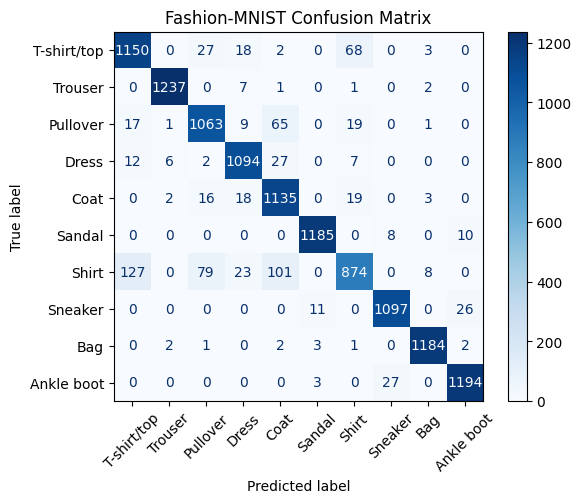

In [6]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 클래스 이름
labels_map = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

class_names = [labels_map[i] for i in range(10)]

# 저장한 최고 모델 불러오기
model = BetterCNN() # BetterCNN 구조의 빈모델 하나 만들기
model.load_state_dict(torch.load("best_model.pth")) # 베스트모델 파일안에 저장된 최고성능일때의 가중치를 현재 모델에 적용 / load_state_dict = 읽어온 가중치 모델안에 적용하기
                                                    # torch.load 파일안에 저장된 가중치 정보를 읽어오기
model = model.to(device)
model.eval()

all_preds = [] # 모든 예측값을 모아둘 리스트
all_labels = [] # 모든 정답값을 모아둘 리스트 / confusion matrix는 데이터 전체기준으로 만들어야해서 한 batch씩 예측한걸 전부 모아야함

with torch.no_grad(): # 평가할 때 gradient 계산 X
    for images, labels in valid_loader: # valid 데이터를 설정한 batch 크기 값씩 꺼내오기
        images, labels = images.to(device), labels.to(device)

        outputs = model(images) # 현재 batch 이미지들에 대해 모델이 예측점수를 계산 / shape => (64, 10) 10개의 클래스 각각 점수 부여
        _,predicted = torch.max(outputs, 1) # 가장 큰 점수의 클래스 고르기

        all_preds.extend(predicted.cpu().numpy()) # 이번 batch의 예측 결과를 전체 예측 리스트에 추가 numpy 배열로 바꿔주기 extend 리스트 뒤에 값들 하나씩 이어붙이기
        all_labels.extend(labels.cpu().numpy()) # append는 리스트안에 배열하나가 통째로 들어가서 extend로 배열 안의 값들을 하나씩 추가해줘야함 / 이번 batch의 정답도 전체 정답리스트에 추가
                                                # confusion matrix에는 예측값 vs 실제값이라 둘다 있어야 계산이 가능하다.

# confusion matrix 계산
cm = confusion_matrix(all_labels, all_preds) # 전체 정답과 전체 예측을 비교해서 10x10 표를 만듬 / 행(row) = 실제 정답, 열(column) = 모델 예측 즉, cm[실제][예측] 
                                             # 만약 cm[9][9]가 크면 정답인 ankle boot인 이미지를 잘 맞췄다 라는 뜻 cm[6][0]이 크면 정답은 shirt인데 모델이 T-shirt/top으로 자주 틀렸다는것.

# 시각화
plt.figure(figsize=(10,10)) # 출력할 그림 크기 10x10 설정
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= class_names) # 계산한 confusion matrix를 클래스이름과 함께 보기 좋게 그릴 준비 / confusion_matrix = 우리가 만든 표, display_labels = 숫자 대신 클래스 이름붙이기
disp.plot(cmap="Blues", xticks_rotation=45) # cmap = Blues: 파란색 계열로 시각화, xticks_rotation = 45: x축의 글자를 45도 기울여서 보기좋게 출력하라
plt.title("Fashion-MNIST Confusion Matrix") # 그래프 제목 달기
plt.show()